In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [6]:
# Load the data
df = pd.read_csv("C:\chaitanya\TEKS ACADEMY\All Projects\DA + ML\ML_data.csv")
df

,customer_id,register_to_order,first_to_last_order,total_spent,total_units
0,C328276L,-2,0,20242.0,1
1,C922780L,150,0,4640.0,1
2,C587876L,-31,0,284200.0,1
3,C137906L,15,0,348000.0,1
4,C417601L,44,0,90480.0,1
...,...,...,...,...,...
2859,C653890L,9,0,8410000.0,1
2860,C352487L,-105,95,4245716.0,3
2861,C763154L,15,0,40310.0,1
2862,C865419L,-7,0,232000.0,1


In [7]:
# Group registered first
df_normal = df[df['register_to_order'] >= 0].copy()

# Group pre-registration
df_pre_register = df[df['register_to_order'] < 0].copy()

print('Normal Customer', df_normal.shape[0])
print('Pre-registered Customer', df_pre_register.shape[0])

Normal Customer 1984
Pre-registered Customer 880


In [9]:
features = ['register_to_order',
            'first_to_last_order',
            'total_units',
            'total_spent'
           ]

In [11]:
# Standardization => limit the data range into mean = 0 and standard deviation = 1
# Normalization => limit the data range between 0 and 1

scaler_normal = StandardScaler()
X_normal_scaled = scaler_normal.fit_transform(df_normal[features])

scaler_pre = StandardScaler()
X_pre_scaled = scaler_pre.fit_transform(df_pre_register[features])

In [12]:
# Train the Model
kmeans = KMeans(n_clusters=3, random_state=42)
df_normal['cluster'] = kmeans.fit_predict(X_normal_scaled)

kmeans_pre = KMeans(n_clusters=3, random_state=42)
df_pre_register['cluster'] = kmeans.fit_predict(X_pre_scaled)

In [15]:
# Summary of the Model

cluster_summary = (
    df_normal.groupby('cluster')[features].mean().round(2)
)
cluster_summary

,register_to_order,first_to_last_order,total_units,total_spent
cluster,,,,
0,78.03,2.28,1.88,7.011844e+05
1,77.00,0.00,1000.00,5.187520e+08
2,61.94,224.06,11.11,4.226931e+06


In [16]:
# Summary of the Model

cluster_summary = (
    df_pre_register.groupby('cluster')[features].mean().round(2)
)
cluster_summary

,register_to_order,first_to_last_order,total_units,total_spent
cluster,,,,
0,-28.41,17.29,1.74,706895.32
1,-173.78,65.12,2.61,785313.31
2,-128.27,501.42,31.85,28746276.08


In [36]:
# Mapping()
cluster_labels = {
                 0: "Normal but Low Engagement",
                 1: "Extreme High-Volume",
                 2: "Loyal, High Value Customer"
                 }

df_normal['segment'] = df_normal['cluster'].map(cluster_labels)

df_pre_register['segment'] = df_pre_register['cluster'].map(cluster_labels)

<Axes: xlabel='total_spent', ylabel='total_units'>

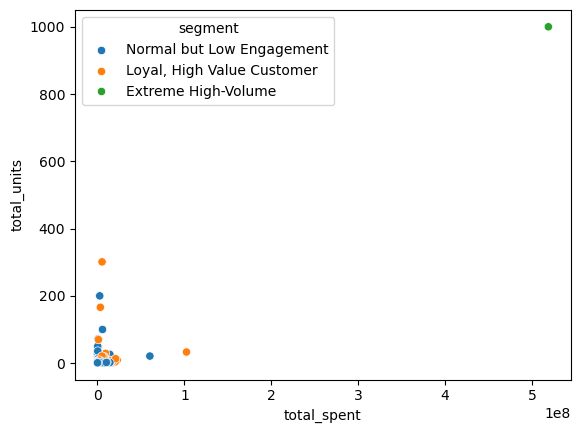

In [37]:
# Visualize the data
sns.scatterplot(data = df_normal, x='total_spent', y='total_units', hue='segment', palette='tab10')

<Axes: xlabel='total_spent', ylabel='total_units'>

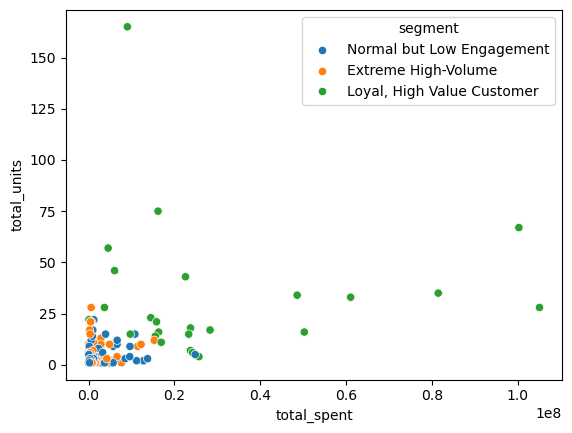

In [38]:
sns.scatterplot(data = df_pre_register, x='total_spent', y='total_units', hue='segment', palette='tab10')

In [39]:
# Combine the data

df_normal['segment_type'] = 'normal'
df_pre_register['segment_type'] = 'pre_register'

In [40]:
# df_normal.head()
df_pre_register.head()

,customer_id,register_to_order,first_to_last_order,total_spent,total_units,cluster,segment_type,segment
0,C328276L,-2,0,20242.0,1,0,pre_register,Normal but Low Engagement
2,C587876L,-31,0,284200.0,1,0,pre_register,Normal but Low Engagement
6,C668740L,-10,0,99760.0,2,0,pre_register,Normal but Low Engagement
8,C942567L,-4,0,43500.0,1,0,pre_register,Normal but Low Engagement
12,C594887L,-42,0,65830.0,1,0,pre_register,Normal but Low Engagement


In [42]:
df_segmented = pd.concat([df_normal, df_pre_register])

In [43]:
df_segmented.head()

,customer_id,register_to_order,first_to_last_order,total_spent,total_units,cluster,segment,segment_type
1,C922780L,150,0,4640.0,1,0,Normal but Low Engagement,normal
3,C137906L,15,0,348000.0,1,0,Normal but Low Engagement,normal
4,C417601L,44,0,90480.0,1,0,Normal but Low Engagement,normal
5,C283866L,8,84,16691066.0,14,0,Normal but Low Engagement,normal
7,C922671L,109,206,319000.0,10,2,"Loyal, High Value Customer",normal


In [44]:
# Save the data
df_segmented.to_excel('customer_segment.xlsx', index=False)